# HMM Labeller

This notebook is strictly for offline amplitude labels and online HMM state filtering. The offline amplitude labels use future price information and are for training/evaluation only; the online state probabilities are what can be used live.

In [1]:
from __future__ import annotations

import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from scipy.stats import norm, skewnorm

if "notebooks" not in sys.path:
    sys.path.append("notebooks")

from advanced_features import (
    amplitude_based_labels,
    build_feature_set,
    discover_datasets,
    emission_parameter_table,
    fit_amplitude_hmm_labeller,
    latest_feature_date,
)

ROOT = Path(os.environ.get("MODL_WS_NORMALIZED_DIR", "/mnt/burner-archive/ws_normalized")).expanduser()
DATE = os.environ.get("MODL_VIEW_DATE") or latest_feature_date(ROOT)
DATE_TAG = datetime.strptime(DATE, "%Y-%m-%d").strftime("%y-%m-%d")
BAR_MINUTES = int(os.environ.get("MODL_BAR_MINUTES", "5"))
HORIZONS = (5, 15, 30)
MINAMP_BPS = float(os.environ.get("MODL_HMM_MINAMP_BPS", "100"))
INACTIVE_BARS = int(os.environ.get("MODL_HMM_INACTIVE_BARS", "10"))
TRAIN_FRACTION = float(os.environ.get("MODL_HMM_TRAIN_FRACTION", "0.7"))

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 240)
pd.set_option("display.max_colwidth", 180)
pl.Config.set_tbl_cols(240)
pl.Config.set_tbl_rows(24)

DATASETS = discover_datasets(ROOT, DATE_TAG)
if not DATASETS:
    raise FileNotFoundError(f"No normalized Parquet files found under {ROOT} for {DATE}")

ROOT, DATE, DATE_TAG, BAR_MINUTES, MINAMP_BPS, INACTIVE_BARS, len(DATASETS)

(PosixPath('/mnt/burner-archive/ws_normalized'),
 '2026-06-30',
 '26-06-30',
 5,
 100.0,
 10,
 14)

## Build Reference Price

In [2]:
feature_set = build_feature_set(DATASETS, horizons=HORIZONS, bar_minutes=BAR_MINUTES)
reference_price = feature_set.reference_price
reference_price.tail(20)

minute
2026-06-30 03:25:00    59831.423963
2026-06-30 03:30:00    59769.251564
2026-06-30 03:35:00    59740.519747
2026-06-30 03:40:00    59721.902273
2026-06-30 03:45:00    59645.717255
2026-06-30 03:50:00    59634.699798
2026-06-30 03:55:00    59594.077475
2026-06-30 04:00:00    59552.554798
2026-06-30 04:05:00    59478.792281
2026-06-30 04:10:00    59475.316970
2026-06-30 04:15:00    59472.351009
2026-06-30 04:20:00    59456.246771
2026-06-30 04:25:00    59505.170152
2026-06-30 04:30:00    59589.934242
2026-06-30 04:35:00    59622.567709
2026-06-30 04:40:00    59551.298232
2026-06-30 04:45:00    59538.640616
2026-06-30 04:50:00    59512.180560
2026-06-30 04:55:00    59383.704545
2026-06-30 05:00:00    59486.759966
Freq: 5min, Name: book_mid_hibachi, dtype: float64

## Offline Amplitude Labels

In [3]:
offline_labels = amplitude_based_labels(
    reference_price,
    minamp_bps=MINAMP_BPS,
    inactive_bars=INACTIVE_BARS,
    apply_ols_filter=True,
)
offline_labels["ret"] = np.log(offline_labels["price"]).diff()
offline_labels["label"].value_counts().sort_index().rename("count").to_frame()

,count
label,
0,21


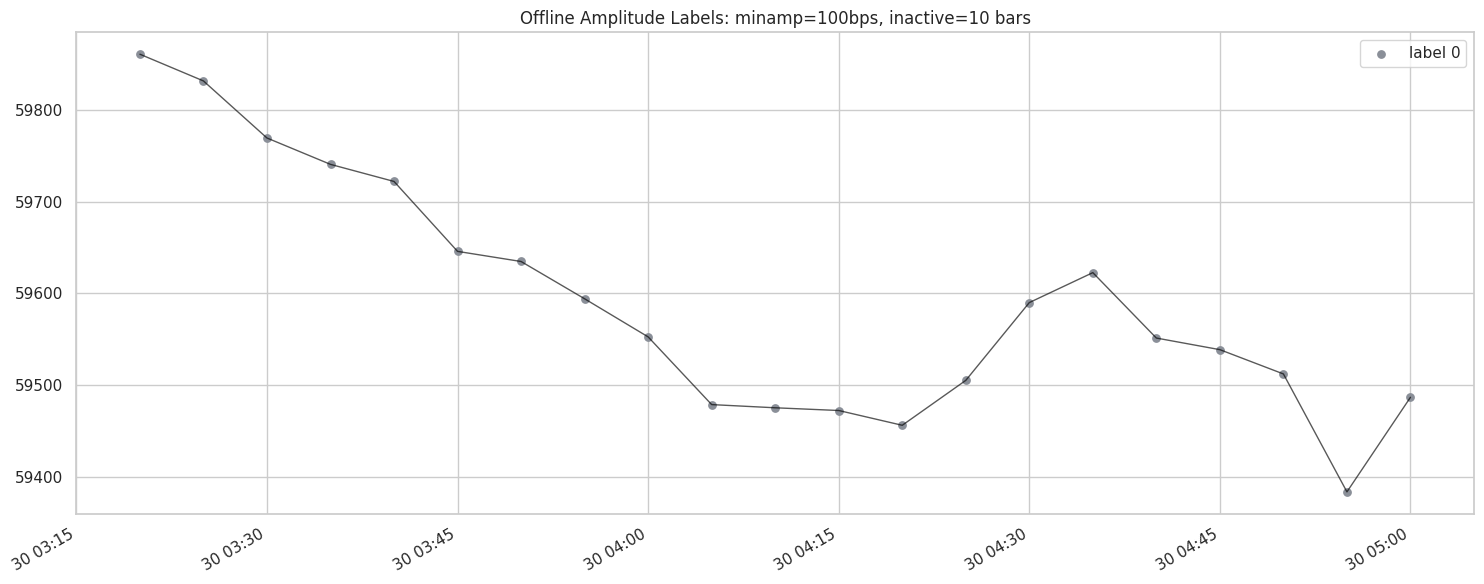

In [4]:
label_colors = {-1: "#cc4c4c", 0: "#8a8f98", 1: "#2f6fdd"}
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(offline_labels.index, offline_labels["price"], color="black", linewidth=1, alpha=0.65)
for label, group in offline_labels.groupby("label"):
    ax.scatter(group.index, group["price"], s=28, color=label_colors.get(int(label), "gray"), label=f"label {int(label)}")
ax.set_title(f"Offline Amplitude Labels: minamp={MINAMP_BPS:g}bps, inactive={INACTIVE_BARS} bars")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()

## Fit HMM

In [5]:
hmm = fit_amplitude_hmm_labeller(
    reference_price,
    minamp_bps=MINAMP_BPS,
    inactive_bars=INACTIVE_BARS,
    train_fraction=TRAIN_FRACTION,
)
print("state_probability", hmm.state_probability.shape)
print("states", hmm.states.value_counts().sort_index().to_dict())
hmm.diagnostics.get("emissions")

state_probability (20, 3)
states {0: 20}


,state,distribution,n,mean,std
0,-1,norm,0,-0.000324,0.000713
1,0,norm,14,-0.000324,0.000713
2,1,norm,0,-0.000324,0.000713


In [6]:
hmm.transition_matrix

,-1,0,1
-1,0.333333,0.333333,0.333333
0,0.062500,0.875000,0.062500
1,0.333333,0.333333,0.333333


In [7]:
hmm.start_probability.rename("start_probability").to_frame()

,start_probability
-1,0.25
0,0.50
1,0.25


## Online State Probabilities

In [8]:
state_probability = hmm.state_probability.copy()
state_probability["hmm_state"] = hmm.states
state_probability.tail(20)

,state_-1,state_0,state_1,hmm_state
minute,,,,
2026-06-30 03:25:00,0.250000,0.500000,0.250000,0
2026-06-30 03:30:00,0.197917,0.604167,0.197917,0
2026-06-30 03:35:00,0.169705,0.660590,0.169705,0
2026-06-30 03:40:00,0.154423,0.691153,0.154423,0
2026-06-30 03:45:00,0.146146,0.707708,0.146146,0
2026-06-30 03:50:00,0.141662,0.716675,0.141662,0
2026-06-30 03:55:00,0.139234,0.721532,0.139234,0
2026-06-30 04:00:00,0.137918,0.724163,0.137918,0
2026-06-30 04:05:00,0.137206,0.725588,0.137206,0


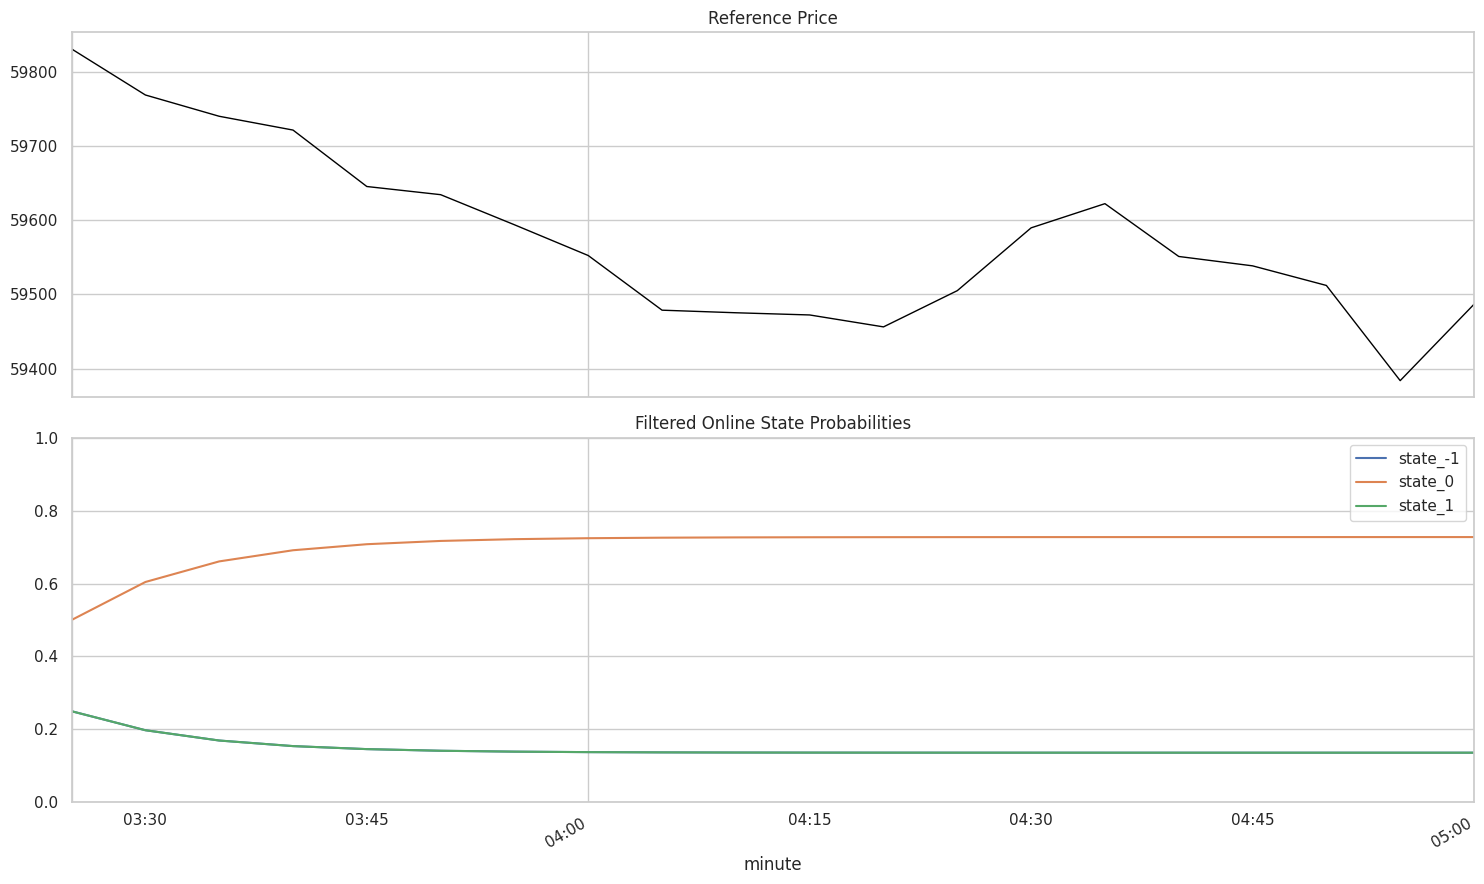

In [9]:
if not hmm.state_probability.empty:
    fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
    reference_price.reindex(hmm.state_probability.index).plot(ax=axes[0], color="black", linewidth=1)
    axes[0].set_title("Reference Price")
    hmm.state_probability.plot(ax=axes[1], linewidth=1.5)
    axes[1].set_title("Filtered Online State Probabilities")
    axes[1].set_ylim(0, 1)
    fig.autofmt_xdate()
    plt.tight_layout()
else:
    print("No HMM probabilities available")

## Emission Fit Diagnostics

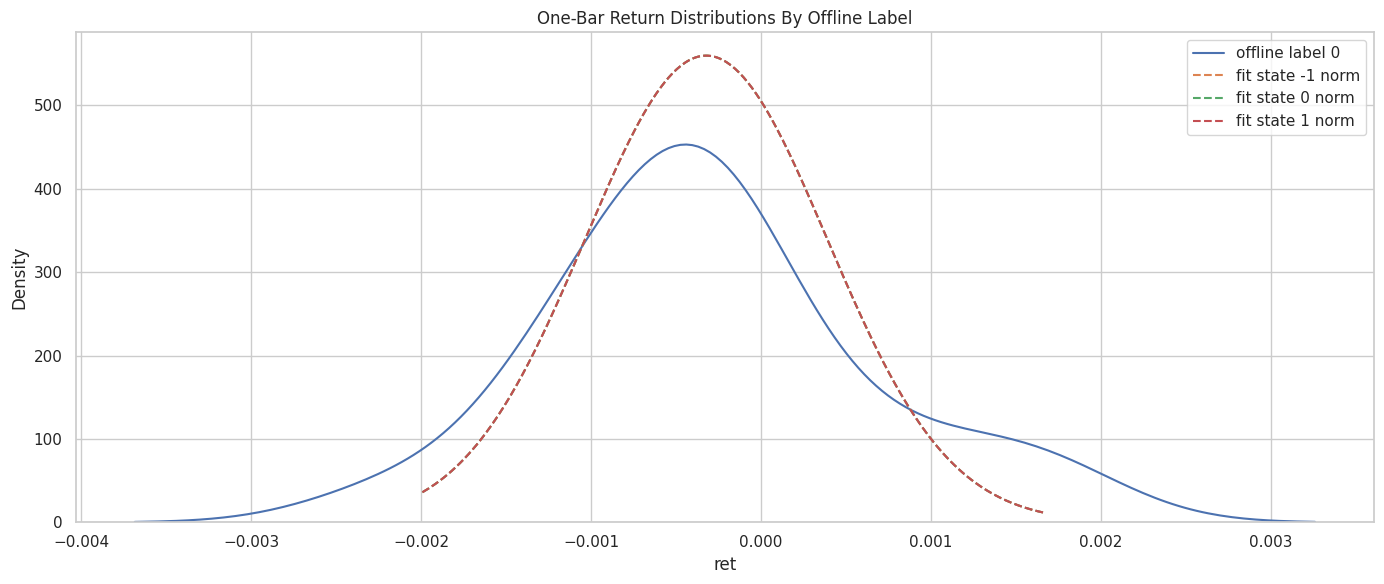

In [10]:
plot_df = offline_labels.replace([np.inf, -np.inf], np.nan).dropna(subset=["ret", "label"])
fig, ax = plt.subplots(figsize=(14, 6))
for label, group in plot_df.groupby("label"):
    sns.kdeplot(group["ret"], ax=ax, label=f"offline label {int(label)}", fill=False)

x = np.linspace(plot_df["ret"].quantile(0.01), plot_df["ret"].quantile(0.99), 300) if len(plot_df) >= 3 else np.linspace(-0.001, 0.001, 300)
for emission in hmm.emissions:
    if emission.distribution == "skewnorm":
        y = skewnorm.pdf(x, *emission.params)
    else:
        y = norm.pdf(x, *emission.params)
    ax.plot(x, y, linestyle="--", label=f"fit state {emission.state} {emission.distribution}")
ax.set_title("One-Bar Return Distributions By Offline Label")
ax.legend()
plt.tight_layout()

## Offline Label Vs Online HMM State

In [11]:
hmm.diagnostics.get("confusion_all")

hmm_state,-1,0,1
offline_label,,,
-1,0,0,0
0,0,20,0
1,0,0,0


In [12]:
hmm.diagnostics.get("classification_all")

,state,precision,recall,f1,support
0,-1,NaN,NaN,NaN,0
1,0,1.0,1.0,1.0,20
2,1,NaN,NaN,NaN,0


In [13]:
hmm.diagnostics.get("confusion_test")

hmm_state,-1,0,1
offline_label,,,
-1,0,0,0
0,0,6,0
1,0,0,0


## Notes

- Offline labels are allowed to look forward and are not tradable directly.
- HMM filtering uses only returns up to the current bar once emissions and transitions are fitted.
- With one partial/corrupted day, state counts may be degenerate. Re-run this after syncing complete days before trusting transition or emission stability.